# Proyecto 2 – Resultados
### Data Science

**Reto 18: Hackeando el cuerpo humano**. [HuBMAP - Hacking the Human Body](https://www.kaggle.com/competitions/hubmap-organ-segmentation)

Segmentación de unidades funcionales de tejido (FTU) en imágenes histológicas de cinco órganos: riñón, intestino grueso, pulmón, próstata y bazo.

Este notebook se trabaja en cadena, según `docs/division_avances_resultados.md`:

| Sección | Responsable |
| --- | --- |
| 1. Investigación y selección de modelos | Completada |
| 2. Pipeline de datos | Persona 1 |
| 3. Entrenamiento de los modelos | Persona 2 |
| 4. Evaluación, comparación y visualizaciones | Persona 3 |

Se corre en local. Los datos van en `data/`: `train.csv` y la carpeta `train_images/` (ver el README). Antes de pasar el turno, cada persona sube el notebook ejecutado al repositorio con su commit.

---
## Configuración inicial

In [1]:
import os
import sys
import time

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "data/"
IMG_DIR = DATA_DIR + "train_images/"

# Código compartido del preprocesamiento
sys.path.insert(0, "src")
import preprocess as pp

CACHE_DIR = os.path.join(DATA_DIR, f"cache_{pp.IMG_SIZE}")

# Los .tiff originales solo se necesitan para CREAR la caché. Con la caché ya
# generada, el pipeline, la evaluación y la app funcionan sin los 5.8 GB.
HAY_IMAGENES = os.path.isdir(IMG_DIR) and len(os.listdir(IMG_DIR)) > 0
HAY_CACHE = os.path.isdir(CACHE_DIR) and len(os.listdir(CACHE_DIR)) > 0
print(f"TIFF originales: {HAY_IMAGENES} | caché de {pp.IMG_SIZE} px: {HAY_CACHE}")

TIFF originales: True | caché de 384 px: True


---
## 1. Investigación y selección de modelos

Las referencias completas en formato APA están en `informe/referencias.bib`.

### 1.1 Revisión bibliográfica

**Contexto del problema**

| Referencia | Aporte al proyecto |
| --- | --- |
| Jain et al. (2023a), *Nature Communications* | Artículo oficial del reto. Describe el dataset (880 imágenes de HPA y HuBMAP, 351 de entrenamiento), la métrica (Dice promedio) y las soluciones ganadoras. |
| Jain et al. (2023b), *Communications Biology* | Competencia anterior de HuBMAP (solo glomérulos de riñón). Muestra que el modelo ganador se integró al portal de HuBMAP para segmentar a escala. |
| HuBMAP Consortium (2019), *Nature* | Objetivos del programa HuBMAP: construir un atlas de referencia del cuerpo humano a nivel celular. |
| de Bono et al. (2013), *Journal of Biomedical Semantics* | Definición de unidad funcional de tejido (FTU): bloque de células alrededor de un capilar, dentro de la distancia de difusión. |
| Bidanta et al. (2025), *Nature Communications* | Catálogo de 22 FTU en 10 órganos, con sus dimensiones y composición celular. |

**Aprendizaje profundo en imagen médica**

| Referencia | Aporte al proyecto |
| --- | --- |
| Litjens et al. (2017), *Medical Image Analysis* | Revisión de más de 300 trabajos. Las redes convolucionales dominan clasificación, detección y segmentación en imagen médica. |
| Siddique et al. (2021), *IEEE Access* | Revisión de U-Net y sus variantes (U-Net++, Attention U-Net, etc.) en distintas modalidades médicas. |
| Isensee et al. (2021), *Nature Methods* | nnU-Net: una U-Net bien configurada (preprocesamiento, entrenamiento, posprocesamiento) supera a arquitecturas más especializadas en 23 datasets. |

**Arquitecturas de segmentación**

| Referencia | Aporte al proyecto |
| --- | --- |
| Ronneberger et al. (2015), *MICCAI* | U-Net: encoder-decoder con conexiones de salto. Funciona con pocas imágenes gracias al data augmentation. |
| Zhou et al. (2020), *IEEE Transactions on Medical Imaging* | U-Net++: rediseña las conexiones de salto para combinar características de varias escalas. |
| Chen et al. (2018), *ECCV* | DeepLabV3+: convoluciones atrous y un decoder que mejora los bordes de los objetos. |
| Xie et al. (2021), *NeurIPS* | SegFormer: encoder transformer jerárquico con decoder MLP ligero, sin codificación posicional. |
| Xu et al. (2021), *ICCV* | CoaT: transformer con atención convolucional, usado como alternativa a SegFormer en el reto. |

**Preprocesamiento y función de pérdida**

| Referencia | Aporte al proyecto |
| --- | --- |
| Macenko et al. (2009), *IEEE ISBI* | Método clásico de normalización de tinción en histología. |
| Tellez et al. (2019), *Medical Image Analysis* | Compara augmentation de color y normalización de tinción con imágenes H&E de 4 órganos y 9 laboratorios. |
| Milletari et al. (2016), *3DV* | Propone la pérdida Dice para manejar el desbalance entre fondo y objeto. |

### 1.2 Hallazgos de las soluciones ganadoras del reto

Según Jain et al. (2023a):

- Los tres primeros lugares obtuvieron un Dice promedio de 0.835, 0.833 y 0.832 en el test privado.
- **Riñón** e **intestino grueso** fueron los órganos más fáciles; **pulmón** fue el más difícil (Dice ≈ 0.72 a 0.74), por la variación en la forma de los alvéolos.
- Las estrategias más efectivas fueron: ensambles con al menos un vision transformer, datos externos con pseudo-etiquetado, y data augmentation fuerte o normalización de tinción.
- **SegFormer** fue el mejor transformer. Como modelo individual (mit-b4) llegó a un Dice de 0.828, casi igual que el ensamble completo. **CoaT** rindió igual; **Swin** rindió mal.
- El tercer lugar adaptó el tamaño de píxel e hizo *histogram matching* entre imágenes de HPA y HuBMAP.

### 1.3 Selección de modelos


| Modelo | Tipo | Justificación |
| --- | --- | --- |
| U-Net con encoder ResNet34 | CNN (baseline) | Arquitectura de referencia en segmentación biomédica (Ronneberger et al., 2015; Siddique et al., 2021). nnU-Net muestra que sigue siendo muy competitiva (Isensee et al., 2021). |
| U-Net++ | CNN mejorada | Conexiones de salto multiescala, útiles porque el tamaño de las FTU varía mucho entre órganos (Zhou et al., 2020). |
| SegFormer | Transformer | Mejor modelo individual en el reto (Jain et al., 2023a; Xie et al., 2021). Permite comparar CNN contra transformer. |

Alternativas si algún modelo no funciona: DeepLabV3+ (Chen et al., 2018) o CoaT (Xu et al., 2021).

**Métricas de evaluación**

- **Dice** (métrica oficial del reto), promedio y por órgano.
- **IoU**, como métrica complementaria.
- Tiempo de entrenamiento y de inferencia.

**Función de pérdida sugerida:** Dice + BCE (Milletari et al., 2016).

**Preprocesamiento sugerido para la Persona 1:** normalización de tinción o augmentation de color (Macenko et al., 2009; Tellez et al., 2019) y ajuste del tamaño de píxel entre fuentes (Jain et al., 2023a).

---
## 2. Pipeline de datos

Todo el preprocesamiento está en `src/preprocess.py`, para que el entrenamiento, la evaluación y la aplicación usen exactamente los mismos pasos. En esta sección se explica y se verifica cada paso.

| Paso | Función en `preprocess.py` |
| --- | --- |
| Decodificar máscaras | `rle_decode`, `rle_encode` |
| Leer y redimensionar | `leer_imagen`, `ajustar_tamano_pixel`, `redimensionar`, `preparar_cache` |
| Data augmentation | `transformaciones` |
| División de los datos | `crear_splits` |
| Dataset y DataLoaders | `HubmapDataset`, `crear_dataloaders` |
| Imagen nueva (para la app) | `preprocesar_para_modelo`, `postprocesar` |

In [2]:
train = pd.read_csv(DATA_DIR + "train.csv")
print(train.shape)
train.head()

(351, 10)


,id,organ,data_source,img_height,img_width,pixel_size,tissue_thickness,rle,age,sex
0,10044,prostate,HPA,3000,3000,0.4,4,1459676 77 1462675 82 1465674 87 1468673 92 14...,37.0,Male
1,10274,prostate,HPA,3000,3000,0.4,4,715707 2 718705 8 721703 11 724701 18 727692 3...,76.0,Male
2,10392,spleen,HPA,3000,3000,0.4,4,1228631 20 1231629 24 1234624 40 1237623 47 12...,82.0,Male
3,10488,lung,HPA,3000,3000,0.4,4,3446519 15 3449517 17 3452514 20 3455510 24 34...,78.0,Male
4,10610,spleen,HPA,3000,3000,0.4,4,478925 68 481909 87 484893 105 487863 154 4908...,21.0,Female


### 2.1 Decodificación de máscaras RLE

Las anotaciones vienen en `train.csv` como *run-length encoding*: pares de números (píxel inicial, cantidad de píxeles seguidos que pertenecen a una FTU). No hay archivos de máscara aparte.

En esta competencia los píxeles se numeran **de arriba hacia abajo y luego de izquierda a derecha** (por columnas). Si se reconstruye por filas, la máscara queda transpuesta y no coincide con el tejido. Por eso `rle_decode` usa `order="F"`.

Para comprobar que la decodificación es correcta, se decodifica y se vuelve a codificar cada máscara: el resultado debe ser idéntico al RLE original.

In [3]:
t0 = time.time()
errores = 0
for fila in train.itertuples():
    mask = pp.rle_decode(fila.rle, (fila.img_height, fila.img_width))
    if pp.rle_encode(mask) != fila.rle.strip():
        errores += 1
print(f"Máscaras verificadas: {len(train)} | errores: {errores} | {time.time() - t0:.1f} s")

Máscaras verificadas: 351 | errores: 0 | 8.1 s


### 2.2 Redimensionamiento y ajuste del tamaño de píxel

Las imágenes miden ~3000×3000 px, demasiado para caber en la memoria de la GPU al entrenar. Se redimensionan a **384×384 px** (`pp.IMG_SIZE`). El segundo lugar del reto encontró que resoluciones de entrada más grandes funcionaban mejor (Jain et al., 2023a), pero 768 px con estos tres modelos no cabe en una GPU portátil de 6 a 8 GB: 384 px es el punto donde el flujo completo sí se puede ejecutar y es la resolución con la que se entrenaron los checkpoints, así que la evaluación y la aplicación usan exactamente la misma. Las imágenes se reducen con interpolación por área y las máscaras con vecino más cercano, para que sigan siendo binarias.

**Tamaño de píxel.** Todas las imágenes de entrenamiento vienen de HPA con 0.4 µm por píxel, pero el test oculto de la competencia y las imágenes que se suban a la aplicación pueden venir de otras fuentes (HuBMAP) con otro tamaño de píxel. Una FTU se vería más grande o más pequeña de lo que el modelo aprendió. `ajustar_tamano_pixel` reescala la imagen para llevarla a 0.4 µm antes de redimensionarla, igual que hizo el tercer lugar del reto (Jain et al., 2023a).

In [4]:
print(train[["data_source", "pixel_size", "tissue_thickness"]].value_counts())
print()
print(train[["img_height", "img_width"]].describe().loc[["min", "50%", "max"]])

data_source  pixel_size  tissue_thickness
HPA          0.4         4                   351
Name: count, dtype: int64

     img_height  img_width
min      2308.0     2308.0
50%      3000.0     3000.0
max      3070.0     3070.0


Leer un `.tiff` de 3000×3000 px en cada época es muy lento. `preparar_cache` guarda cada imagen y su máscara ya redimensionadas como `.png` una sola vez; después el `Dataset` lee de esa caché. Se guarda en `data/cache_384/` (702 archivos: 351 imágenes y 351 máscaras), que no se sube al repositorio.

Esta es la **única** caché del proyecto: la usan el entrenamiento de la sección 3, la evaluación de la sección 4 y la aplicación. Los `.tiff` originales solo hacen falta para generarla; una vez creada se puede trabajar sin los 5.8 GB de descarga, que es como la recibe la Persona 3.

In [5]:
if HAY_IMAGENES:
    t0 = time.time()
    pp.preparar_cache(train, IMG_DIR, CACHE_DIR, size=pp.IMG_SIZE)
    print(f"Caché lista en {CACHE_DIR} ({time.time() - t0:.0f} s)")
elif HAY_CACHE:
    print(f"Sin TIFF originales, pero la caché ya está en {CACHE_DIR}: con eso basta.")
else:
    print("Falta la caché y los TIFF. Pide data/cache_384/ por Drive o descarga train_images/ (ver el README).")

# Se recalcula: la línea anterior pudo haber creado la caché en esta misma ejecución.
HAY_CACHE = os.path.isdir(CACHE_DIR) and len(os.listdir(CACHE_DIR)) > 0
archivos_cache = len(os.listdir(CACHE_DIR)) if HAY_CACHE else 0
print(f"Archivos en la caché: {archivos_cache} (se esperan 702 = 351 imágenes × 2)")

Caché lista en data/cache_384 (0 s)
Archivos en la caché: 702 (se esperan 702 = 351 imágenes × 2)


In [6]:
if HAY_CACHE:
    # La proporción de FTU debe mantenerse después de redimensionar
    comparacion = []
    for fila in train.itertuples():
        mask_cache = cv2.imread(os.path.join(CACHE_DIR, f"{fila.id}_mask.png"), cv2.IMREAD_GRAYSCALE)
        area_original = sum(map(int, fila.rle.split()[1::2])) / (fila.img_height * fila.img_width)
        comparacion.append((fila.organ, area_original, mask_cache.mean()))
    comparacion = pd.DataFrame(comparacion, columns=["organ", "original", "redimensionada"])
    comparacion["diferencia"] = (comparacion["redimensionada"] - comparacion["original"]).abs()
    print(comparacion.groupby("organ")[["original", "redimensionada", "diferencia"]].mean().round(4))

                original  redimensionada  diferencia
organ                                               
kidney            0.0302          0.0302      0.0000
largeintestine    0.1934          0.1934      0.0001
lung              0.0208          0.0208      0.0000
prostate          0.1540          0.1540      0.0001
spleen            0.1010          0.1010      0.0001


### 2.3 Normalización de tinción y data augmentation

Las imágenes vienen de distintos laboratorios y la intensidad de la tinción cambia entre ellas. Los ganadores del reto señalaron la normalización de tinción y el augmentation fuerte como de las estrategias más efectivas (Jain et al., 2023a). Tellez et al. (2019) encontraron que el augmentation de color es lo que más mejora la generalización entre laboratorios, así que se usa augmentation de color en lugar de normalizar cada imagen a una tinción de referencia (Macenko et al., 2009).

**Entrenamiento** (`pp.transformaciones("train")`):

| Tipo | Transformación | Por qué |
| --- | --- | --- |
| Geométrica | Volteos horizontal y vertical, rotaciones de 90°, rotación de ±30° y escala de 0.8 a 1.2 | El tejido no tiene una orientación fija y las FTU varían de tamaño |
| Color | Tono, saturación y brillo (HSV), brillo y contraste, gamma | Simula diferencias de tinción entre laboratorios |
| Desenfoque | Gaussiano leve | Simula imágenes escaneadas con menos nitidez |

**Validación y prueba** (`pp.transformaciones("val")`): solo redimensionar y normalizar.

Al final se normaliza con la media y desviación de ImageNet, porque los encoders de los tres modelos vienen preentrenados en ImageNet.

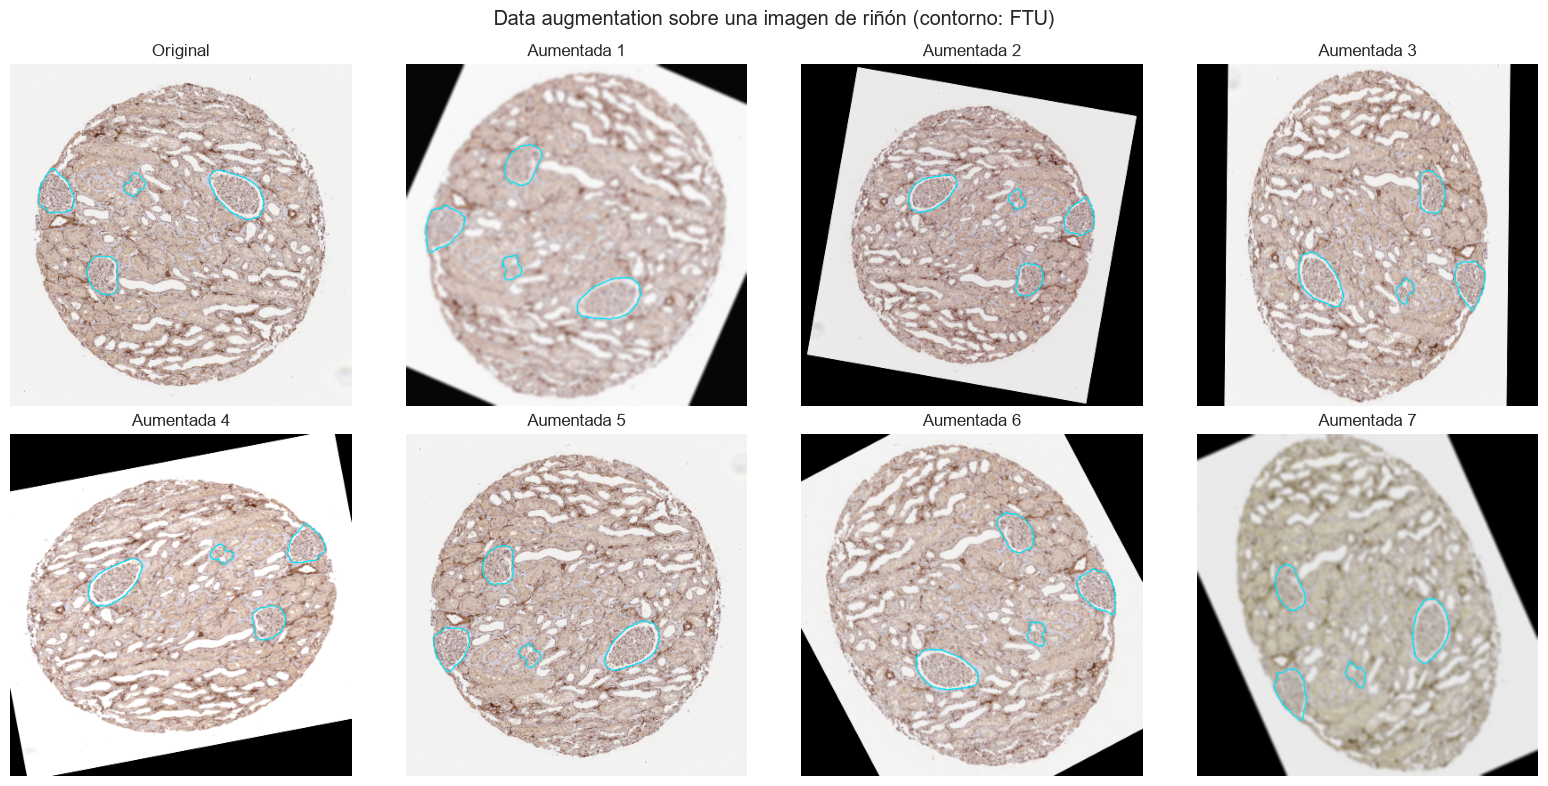

In [7]:
if HAY_CACHE:
    ejemplo = train[train["organ"] == "kidney"].iloc[0]
    img = cv2.cvtColor(cv2.imread(os.path.join(CACHE_DIR, f"{ejemplo['id']}.png")), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(CACHE_DIR, f"{ejemplo['id']}_mask.png"), cv2.IMREAD_GRAYSCALE)

    # Mismas transformaciones de entrenamiento, sin normalizar, para poder verlas
    aug_visual = A.Compose(pp.transformaciones("train").transforms[:-2])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for k, ax in enumerate(axes.flat):
        out = {"image": img, "mask": mask} if k == 0 else aug_visual(image=img, mask=mask)
        ax.imshow(out["image"])
        ax.contour(out["mask"], levels=[0.5], colors="#00e5ff", linewidths=0.8)
        ax.set_title("Original" if k == 0 else f"Aumentada {k}")
        ax.axis("off")
    fig.suptitle("Data augmentation sobre una imagen de riñón (contorno: FTU)")
    plt.tight_layout()
    plt.show()

### 2.4 División en entrenamiento, validación y prueba

Se usa una división **70 / 15 / 15 estratificada por órgano**. El dataset es pequeño (351 imágenes) y desbalanceado: hay 99 de riñón pero solo 48 de pulmón. Sin estratificar, un órgano podría quedar casi sin imágenes en validación o prueba, y las métricas por órgano no serían confiables.

- **Entrenamiento:** para ajustar los pesos de los modelos.
- **Validación:** para elegir hiperparámetros y el mejor checkpoint (early stopping).
- **Prueba:** solo se usa al final para comparar los modelos, así la comparación no está sesgada.

No se usa el test de la competencia porque sus etiquetas están ocultas.

La división se guarda en `data/splits.csv` y se sube al repositorio, para que la Persona 2 y la Persona 3 usen exactamente las mismas imágenes en cada conjunto.

In [8]:
RUTA_SPLITS = os.path.join(DATA_DIR, "splits.csv")

if os.path.exists(RUTA_SPLITS):
    splits = pd.read_csv(RUTA_SPLITS)
else:
    splits = pp.crear_splits(train)
    splits.to_csv(RUTA_SPLITS, index=False)

tabla = pd.crosstab(splits["organ"], splits["split"])[["train", "val", "test"]]
tabla.loc["Total"] = tabla.sum()
tabla

split,train,val,test
organ,,,
kidney,69,15,15
largeintestine,40,9,9
lung,34,7,7
prostate,65,14,14
spleen,37,8,8
Total,245,53,53


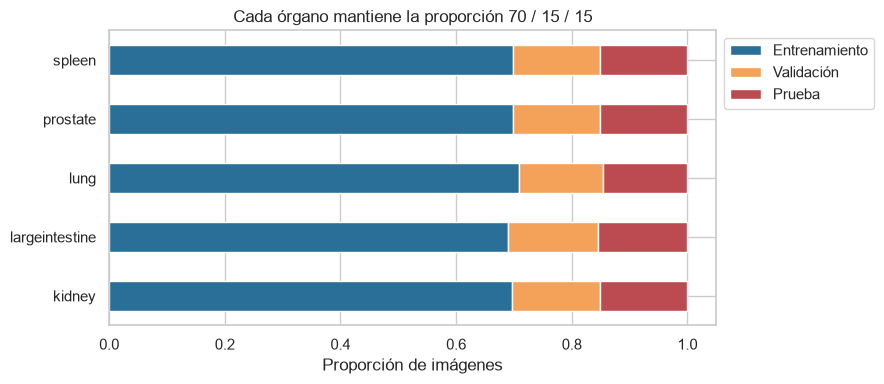

In [9]:
orden = ["train", "val", "test"]
colores = {"train": "#2a6f97", "val": "#f4a259", "test": "#bc4b51"}

proporciones = pd.crosstab(splits["organ"], splits["split"], normalize="index")[orden]
ax = proporciones.plot(kind="barh", stacked=True, figsize=(9, 4), color=[colores[s] for s in orden])
ax.set_xlabel("Proporción de imágenes")
ax.set_ylabel("")
ax.set_title("Cada órgano mantiene la proporción 70 / 15 / 15")
ax.legend(["Entrenamiento", "Validación", "Prueba"], bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### 2.5 Dataset y DataLoaders

`HubmapDataset` lee cada imagen y su máscara de la caché, aplica las transformaciones del conjunto y devuelve un diccionario:

| Clave | Contenido |
| --- | --- |
| `image` | Tensor `float32` de forma `(3, 384, 384)`, normalizado |
| `mask` | Tensor `float32` de forma `(1, 384, 384)`, con valores 0 y 1 |
| `organ` | Nombre del órgano (para calcular métricas por órgano) |
| `id` | Id de la imagen en `train.csv` |

`crear_dataloaders` arma un `DataLoader` por conjunto. Solo el de entrenamiento baraja los datos y aplica augmentation.

El `Dataset` nunca abre un `.tiff`: lee únicamente los `.png` de la caché. Por eso esta celda y las anteriores se condicionan a `HAY_CACHE` y no a `HAY_IMAGENES`.

In [10]:
BATCH_SIZE = 8
loaders = None

if HAY_CACHE:
    loaders = pp.crear_dataloaders(splits, CACHE_DIR, size=pp.IMG_SIZE, batch_size=BATCH_SIZE)
    for nombre, loader in loaders.items():
        print(f"{nombre:5s}: {len(loader.dataset):3d} imágenes, {len(loader):2d} batches")

    batch = next(iter(loaders["train"]))
    print()
    print("image:", tuple(batch["image"].shape), batch["image"].dtype)
    print("mask: ", tuple(batch["mask"].shape), batch["mask"].unique().tolist())
    print("organ:", batch["organ"])
else:
    print("Sin caché no hay cargadores. La sección 4 necesita esta celda ejecutada.")

train: 245 imágenes, 31 batches
val  :  53 imágenes,  7 batches
test :  53 imágenes,  7 batches



image: (8, 3, 384, 384) torch.float32
mask:  (8, 1, 384, 384) [0.0, 1.0]
organ: ['spleen', 'lung', 'prostate', 'prostate', 'lung', 'largeintestine', 'kidney', 'prostate']


### 2.6 Verificación visual del pipeline

Una imagen de cada órgano, ya redimensionada, con su máscara superpuesta. Si la decodificación del RLE estuviera mal, el contorno no coincidiría con las estructuras del tejido.

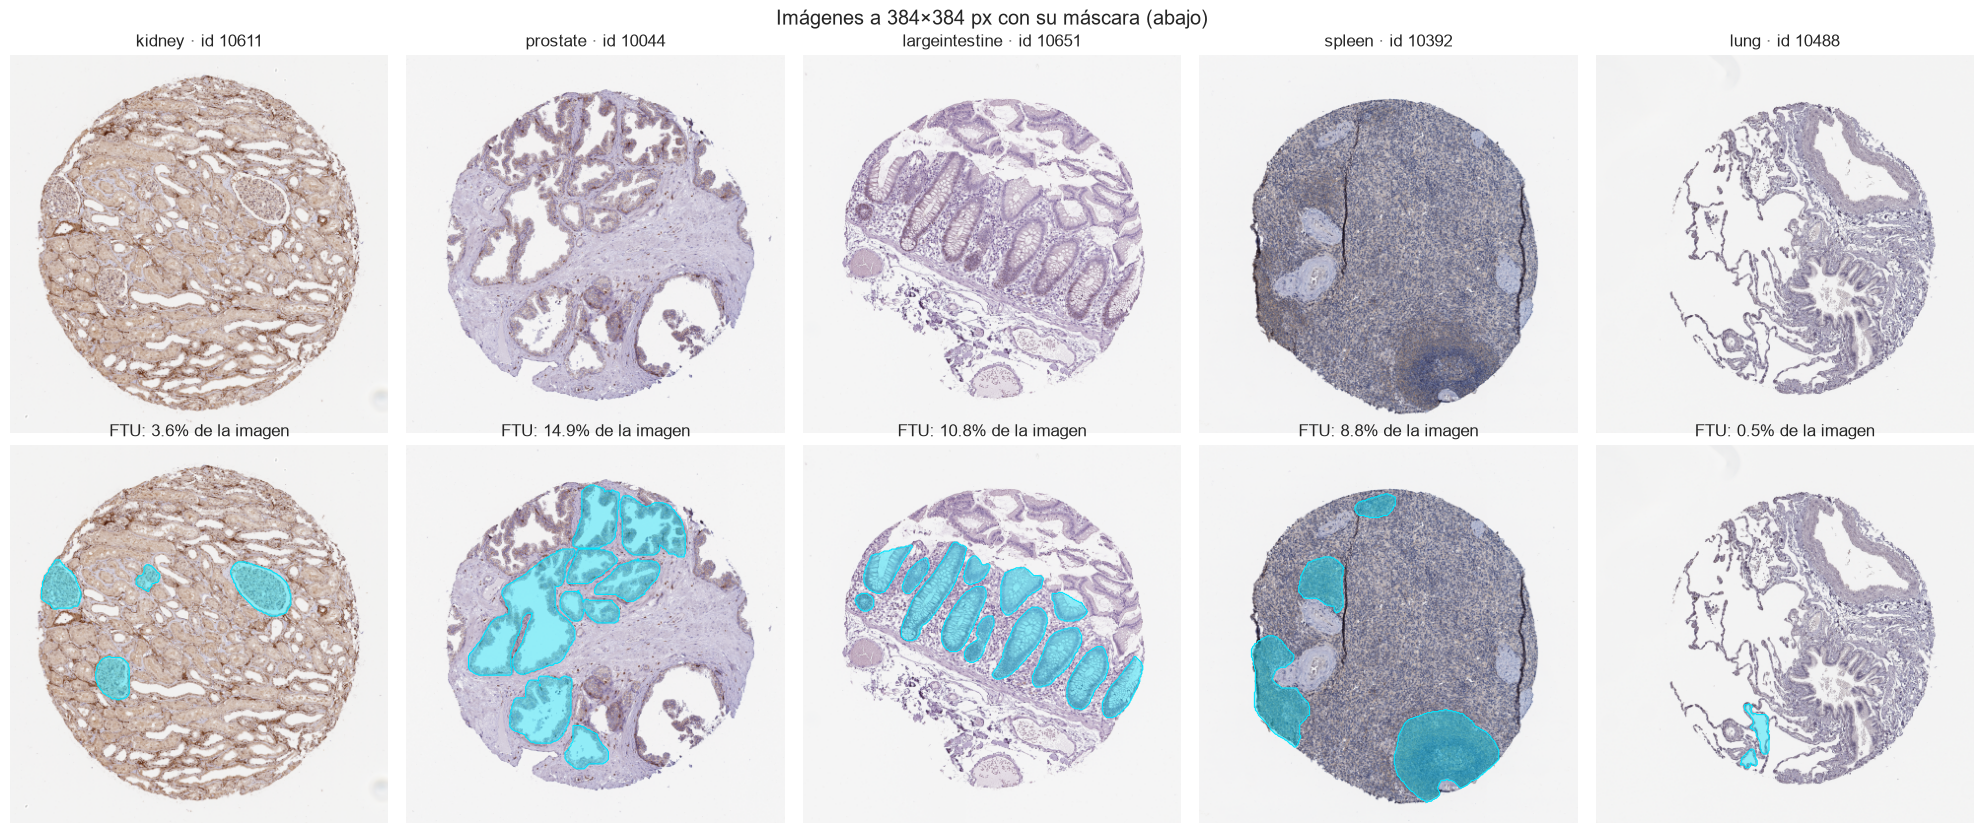

In [11]:
if HAY_CACHE:
    from matplotlib.colors import ListedColormap

    # Cian: contrasta con los tonos rosa y morado de la tinción
    cian = ListedColormap(["#00e5ff"])
    muestra = train.groupby("organ").head(1).set_index("organ").loc[pp.ORGANOS]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
    for j, (organ, fila) in enumerate(muestra.iterrows()):
        img = cv2.cvtColor(cv2.imread(os.path.join(CACHE_DIR, f"{fila['id']}.png")), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(CACHE_DIR, f"{fila['id']}_mask.png"), cv2.IMREAD_GRAYSCALE)

        axes[0, j].imshow(img)
        axes[0, j].set_title(f"{organ} · id {fila['id']}")
        axes[1, j].imshow(img)
        axes[1, j].imshow(np.ma.masked_where(mask == 0, mask), cmap=cian, alpha=0.4, vmin=0, vmax=1)
        axes[1, j].contour(mask, levels=[0.5], colors="#00e5ff", linewidths=0.8)
        axes[1, j].set_title(f"FTU: {mask.mean():.1%} de la imagen")
        for ax in axes[:, j]:
            ax.axis("off")
    fig.suptitle(f"Imágenes a {pp.IMG_SIZE}×{pp.IMG_SIZE} px con su máscara (abajo)")
    plt.tight_layout()
    plt.show()

Un batch de entrenamiento tal como lo recibirá el modelo (se deshace la normalización solo para mostrarlo):

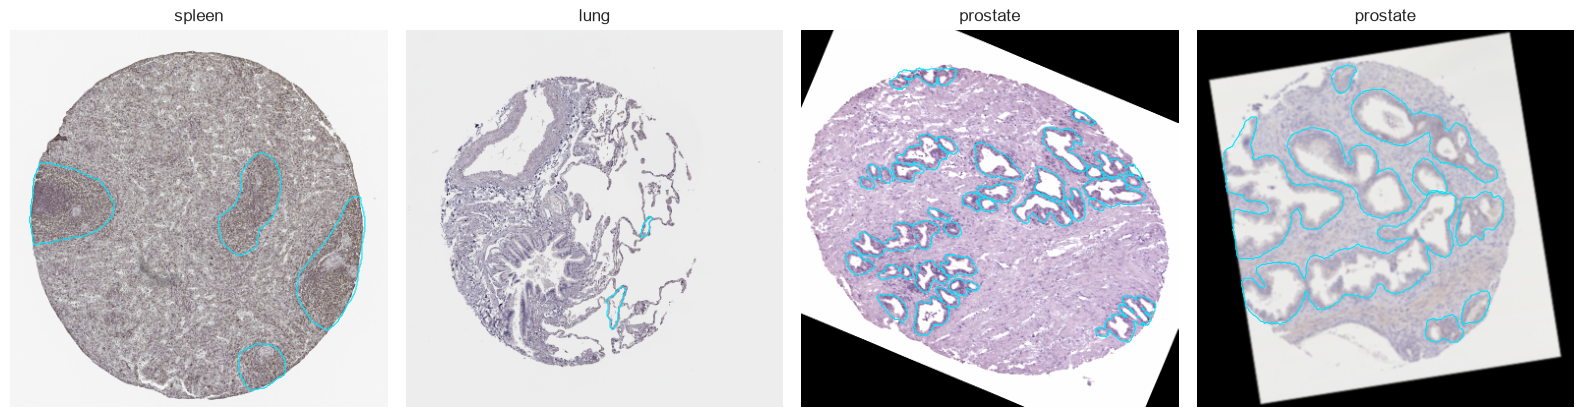

In [12]:
if HAY_CACHE:
    media, desv = np.array(pp.MEAN), np.array(pp.STD)
    n = min(4, BATCH_SIZE)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5))
    for k in range(n):
        img = batch["image"][k].numpy().transpose(1, 2, 0) * desv + media
        axes[k].imshow(np.clip(img, 0, 1))
        axes[k].contour(batch["mask"][k, 0].numpy(), levels=[0.5], colors="#00e5ff", linewidths=0.8)
        axes[k].set_title(batch["organ"][k])
        axes[k].axis("off")
    plt.tight_layout()
    plt.show()

### 2.7 Entrega para la Persona 2

Para usar el pipeline en la sección 3 solo se necesita:

```python
loaders = pp.crear_dataloaders(splits, CACHE_DIR, size=pp.IMG_SIZE, batch_size=BATCH_SIZE)

for batch in loaders["train"]:
    imagenes, mascaras = batch["image"].to(device), batch["mask"].to(device)
    ...
```

- **Tamaño de imagen:** `pp.IMG_SIZE` es 384 px en todo el proyecto. Para probar otro tamaño en el ajuste de hiperparámetros se pasa `size=...` a `preparar_cache` y a `crear_dataloaders`, con otro `CACHE_DIR`; los checkpoints entregados son de 384 px y la evaluación debe usar ese valor.
- **Dispositivo:** `device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"` funciona en compus con NVIDIA y en Mac con chip M.
- **Salida del modelo:** debe ser un solo canal `(batch, 1, H, W)` con logits; la pérdida Dice + BCE se calcula contra `batch["mask"]`.
- **SegFormer:** su salida es de 1/4 de la resolución de entrada, así que hay que interpolarla a `(384, 384)` antes de calcular la pérdida.
- **Imágenes nuevas (app):** `pp.preprocesar_para_modelo(img, pixel_size)` prepara la entrada y `pp.postprocesar(probabilidades, tamano_original)` devuelve la máscara al tamaño original.

---
## 3. Entrenamiento de los modelos

Se comparan tres arquitecturas con la misma partición, pérdida Dice + BCE y criterio de selección: el mayor Dice de validación. El conjunto de prueba queda reservado para la evaluación final de la Persona 3.

El perfil conservador para una RTX 4050 Laptop de 6 GB usa imágenes de 384 px, batch físico 1 y acumulación de 2 pasos (batch efectivo 2). Antes del entrenamiento completo, un preflight CUDA prueba cada modelo con forward, logits adaptados, pérdida, backward y un paso AdamW. Las banderas de preparación y entrenamiento empiezan en `False`: ejecutar esta sección no crea caché ni artefactos, descarga pesos, entrena o ejecuta el preflight por accidente.

### 3.1 Configuración reproducible y dispositivo

In [13]:
from pathlib import Path

import torch

from src.models import FABRICAS_MODELOS, crear_modelo
from src.training import ejecutar_preflight_cuda, entrenar_modelo, fijar_semilla

SEMILLA = 42
RESOLUCION = 384
BATCH_ENTRENAMIENTO = 1
ACUMULACION_GRADIENTES = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
EPOCAS = 20
PACIENCIA = 5
PESOS_PREENTRENADOS = True  # ImageNet para ResNet34; Hugging Face para MIT-B0
EJECUTAR_PREPARACION = False
EJECUTAR_ENTRENAMIENTO = False

if torch.cuda.is_available():
    DISPOSITIVO = torch.device("cuda")
elif torch.backends.mps.is_available():
    DISPOSITIVO = torch.device("mps")
else:
    DISPOSITIVO = torch.device("cpu")

fijar_semilla(SEMILLA)
BATCH_EFECTIVO = BATCH_ENTRENAMIENTO * ACUMULACION_GRADIENTES
print(
    f"Dispositivo: {DISPOSITIVO} | resolución: {RESOLUCION} | "
    f"batch físico: {BATCH_ENTRENAMIENTO} | batch efectivo: {BATCH_EFECTIVO}"
)

Dispositivo: cuda | resolución: 384 | batch físico: 1 | batch efectivo: 2


### 3.2 Preparación explícita de caché y cargadores

Cambiar `EJECUTAR_PREPARACION` a `True` crea, si hace falta, la caché específica de 384 px y sus cargadores con batch físico 1. El último lote de entrenamiento no se descarta, por lo que se usan las 245 imágenes.

In [14]:
CACHE_ENTRENAMIENTO = Path(DATA_DIR) / f"cache_{RESOLUCION}"
cargadores_entrenamiento = None

if EJECUTAR_PREPARACION:
    if not HAY_IMAGENES:
        raise FileNotFoundError("Faltan las imágenes de entrenamiento en data/train_images/.")
    pp.preparar_cache(train, IMG_DIR, CACHE_ENTRENAMIENTO, size=RESOLUCION)
    cargadores_entrenamiento = pp.crear_dataloaders(
        splits,
        CACHE_ENTRENAMIENTO,
        size=RESOLUCION,
        batch_size=BATCH_ENTRENAMIENTO,
        num_workers=2,
        drop_last_train=False,
    )
    print("Imágenes para ajuste:", len(cargadores_entrenamiento["train"].dataset))
    print("Imágenes para validación:", len(cargadores_entrenamiento["val"].dataset))
else:
    print("Preparación omitida. Active EJECUTAR_PREPARACION cuando quiera crear la caché de 384 px.")

Preparación omitida. Active EJECUTAR_PREPARACION cuando quiera crear la caché de 384 px.


### 3.3 Fábricas y protocolo común

Las fábricas de `src/models.py` configuran una salida binaria de un canal, sin sigmoide. U-Net y U-Net++ usan ResNet34. SegFormer usa MIT-B0 y entrega logits a menor resolución, que `src.training.entrenar_modelo` interpola al tamaño de la máscara mediante el adaptador común.

Para una prueba completamente offline se debe fijar `PESOS_PREENTRENADOS = False`. Para el entrenamiento real, `True` solicita pesos ImageNet en los encoders ResNet34 y `nvidia/mit-b0` en Hugging Face. La descarga solo ocurre al crear el modelo dentro del bloque de entrenamiento.

In [15]:
CONFIGURACION_MODELOS = {
    "unet_resnet34": "U-Net / ResNet34",
    "unetplusplus_resnet34": "U-Net++ / ResNet34",
    "segformer_mit_b0": "SegFormer / MIT-B0",
}

assert set(CONFIGURACION_MODELOS) == set(FABRICAS_MODELOS)
pd.DataFrame(
    CONFIGURACION_MODELOS.items(),
    columns=["modelo", "arquitectura_encoder"],
)

,modelo,arquitectura_encoder
0,unet_resnet34,U-Net / ResNet34
1,unetplusplus_resnet34,U-Net++ / ResNet34
2,segformer_mit_b0,SegFormer / MIT-B0


### 3.4 Entrenamiento controlado y artefactos

El loop reutilizable aplica AdamW, Dice + BCE, acumulación de gradientes, validación, early stopping y guardado del mejor checkpoint. Al activar el entrenamiento, primero se prueban los tres modelos con un paso CUDA real; solo si todos caben comienza el entrenamiento. El preflight reporta picos asignados y reservados, pero no garantiza memoria futura si otros procesos empiezan a usar la GPU. Todos los artefactos se escriben bajo `data/artefactos_entrenamiento/`, una ruta excluida de Git. No se crean archivos mientras `EJECUTAR_ENTRENAMIENTO` sea `False`.

In [16]:
COLUMNAS_HISTORIAL = [
    "modelo", "epoca", "train_loss", "train_dice", "val_loss", "val_dice",
]
COLUMNAS_EXPERIMENTOS = [
    "modelo", "arquitectura_encoder", "resolucion", "batch",
    "acumulacion_gradientes", "batch_efectivo",
    "learning_rate", "epocas_solicitadas", "epocas_ejecutadas",
    "mejor_epoca", "mejor_val_dice", "checkpoint", "estado",
]
RUTA_ARTEFACTOS = Path(DATA_DIR) / "artefactos_entrenamiento"
RUTA_HISTORIAL = RUTA_ARTEFACTOS / "historial_modelos.csv"
RUTA_EXPERIMENTOS = RUTA_ARTEFACTOS / "experimentos_modelos.csv"

historial_combinado = pd.DataFrame(columns=COLUMNAS_HISTORIAL)
experimentos = pd.DataFrame(columns=COLUMNAS_EXPERIMENTOS)

if EJECUTAR_ENTRENAMIENTO:
    if cargadores_entrenamiento is None:
        raise RuntimeError("Primero active EJECUTAR_PREPARACION y ejecute la celda de cargadores.")
    if DISPOSITIVO.type == "cuda":
        resultados_preflight = ejecutar_preflight_cuda(
            CONFIGURACION_MODELOS,
            lambda nombre: crear_modelo(nombre, pesos_preentrenados=PESOS_PREENTRENADOS),
            resolucion=RESOLUCION,
            batch_size=BATCH_ENTRENAMIENTO,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            amp=True,
        )
        print("Preflight CUDA completado para los tres modelos:")
        print(resultados_preflight.to_string(index=False))
    else:
        print("Preflight CUDA omitido: el dispositivo seleccionado no es CUDA.")
    RUTA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)
    historiales = []
    registros = []

    for nombre, arquitectura in CONFIGURACION_MODELOS.items():
        modelo = crear_modelo(nombre, pesos_preentrenados=PESOS_PREENTRENADOS)
        ruta_checkpoint = RUTA_ARTEFACTOS / "checkpoints" / f"{nombre}.pt"
        resultado = entrenar_modelo(
            modelo,
            cargadores_entrenamiento["train"],
            cargadores_entrenamiento["val"],
            ruta_checkpoint=ruta_checkpoint,
            epocas=EPOCAS,
            paciencia=PACIENCIA,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            dispositivo=DISPOSITIVO,
            amp=(DISPOSITIVO.type == "cuda"),
            seed=SEMILLA,
            acumulacion_gradientes=ACUMULACION_GRADIENTES,
        )
        historial = resultado.historial.assign(modelo=nombre)[COLUMNAS_HISTORIAL]
        historiales.append(historial)
        registros.append({
            "modelo": nombre,
            "arquitectura_encoder": arquitectura,
            "resolucion": RESOLUCION,
            "batch": BATCH_ENTRENAMIENTO,
            "acumulacion_gradientes": ACUMULACION_GRADIENTES,
            "batch_efectivo": BATCH_EFECTIVO,
            "learning_rate": LEARNING_RATE,
            "epocas_solicitadas": EPOCAS,
            "epocas_ejecutadas": len(resultado.historial),
            "mejor_epoca": resultado.mejor_epoca,
            "mejor_val_dice": resultado.mejor_val_dice,
            "checkpoint": str(resultado.ruta_checkpoint),
            "estado": "detencion_temprana" if resultado.detencion_temprana else "completado",
        })
        del modelo
        if DISPOSITIVO.type == "cuda":
            torch.cuda.empty_cache()

    historial_combinado = pd.concat(historiales, ignore_index=True)[COLUMNAS_HISTORIAL]
    experimentos = pd.DataFrame(registros, columns=COLUMNAS_EXPERIMENTOS)
    historial_combinado.to_csv(RUTA_HISTORIAL, index=False)
    experimentos.to_csv(RUTA_EXPERIMENTOS, index=False)
else:
    print("Entrenamiento omitido de forma segura. No se crearon resultados ni checkpoints.")

experimentos

Entrenamiento omitido de forma segura. No se crearon resultados ni checkpoints.


,modelo,arquitectura_encoder,resolucion,batch,acumulacion_gradientes,batch_efectivo,learning_rate,epocas_solicitadas,epocas_ejecutadas,mejor_epoca,mejor_val_dice,checkpoint,estado


### 3.5 Entrega para la Persona 3

**Ejecución realizada el 2026-10-01** en una RTX 4060 Laptop de 8 GB, mediante el arnés de PowerShell (`scripts/windows_training.ps1 -Stage Train`). Las celdas de arriba siguen con sus banderas en `False` a propósito, así que no muestran estos números: están en `data/artefactos_entrenamiento/experimentos_modelos.csv`.

| Modelo | Épocas ejecutadas | Mejor época | Mejor val Dice | Estado |
| --- | --- | --- | --- | --- |
| SegFormer / MIT-B0 | 10 | 5 | **0.6596** | detención temprana |
| U-Net / ResNet34 | 13 | 8 | 0.6058 | detención temprana |
| U-Net++ / ResNet34 | 6 | 1 | 0.5256 | detención temprana |

Perfil usado: 384 px, batch físico 1, acumulación 2 (batch efectivo 2), AMP, AdamW con learning rate 1e-4, 20 épocas solicitadas y paciencia 5. Picos de VRAM medidos en el preflight: 475 MiB (U-Net), 505 MiB (U-Net++) y 186 MiB (SegFormer) sobre 7.45 GB libres.

**Limitación a discutir:** los tres modelos pararon por early stopping, pero el caso de U-Net++ merece matiz. Su mejor época fue la **1** y paró en la 6, mientras su `train_loss` bajaba de 0.63 a 0.31 y su `train_dice` subía de 0.37 a 0.67. Es decir, seguía aprendiendo y lo detuvo el ruido del Dice de validación —solo 53 imágenes de validación y un batch efectivo de 2—, no un estancamiento real. Presentar 0.5256 como el techo de U-Net++ sería engañoso.

Para contexto, los tres primeros lugares del reto llegaron a Dice ≈ 0.835 en el test privado (Jain et al., 2023a), con resoluciones mayores, ensambles de varios modelos y pseudo-etiquetado con datos externos. Aquí se entrenó un único modelo por arquitectura con el perfil conservador que cabe en una GPU portátil.

La Persona 3 recibe dos CSV y tres checkpoints bajo `data/artefactos_entrenamiento/`:

- `historial_modelos.csv`: una fila por época con `modelo, epoca, train_loss, train_dice, val_loss, val_dice` (29 filas en total).
- `experimentos_modelos.csv`: configuración, épocas solicitadas y ejecutadas, mejor época, mejor Dice de validación, checkpoint y estado por modelo.
- `checkpoints/<modelo>.pt`: mejor estado de cada modelo según validación.

**La Persona 3 no necesita descargar las imágenes.** Junto con los artefactos se comparte `data/cache_384/`, así que basta con dejar en su lugar:

```
data/
  splits.csv                     (ya está en el repositorio)
  train.csv                      (16 MB, para órgano y tamaños originales)
  cache_384/                     (702 .png: 351 imágenes y 351 máscaras)
  artefactos_entrenamiento/      (3 checkpoints y los 2 CSV)
```

Con eso la sección 2 se ejecuta completa (`HAY_CACHE` es `True` aunque no haya `.tiff`) y la sección 4 puede usar `loaders["test"]`. Cada checkpoint se carga así:

```python
estado = torch.load(RUTA_ARTEFACTOS / "checkpoints" / f"{nombre}.pt", map_location=DISPOSITIVO)
modelo = crear_modelo(nombre, pesos_preentrenados=False)
modelo.load_state_dict(estado["modelo"])   # el archivo guarda solo el state_dict
modelo.eval()
```

Ojo con **SegFormer**: su salida es `(batch, 1, 96, 96)`, un cuarto de la entrada, así que hay que interpolarla a `(384, 384)` antes de comparar con la máscara. U-Net y U-Net++ ya devuelven `(batch, 1, 384, 384)`.

La inferencia sobre las 53 imágenes de prueba es ligera y corre en CPU en minutos; solo el **tiempo de inferencia** depende del hardware, así que hay que reportar en qué dispositivo se midió.

Esta sección no genera métricas finales ni resultados simulados. La evaluación sobre el conjunto reservado, las métricas por órgano y la comparación final corresponden exclusivamente a la sección 4.

---
## 4. Evaluación, comparación y visualizaciones

Los tres modelos se evalúan sobre el conjunto de prueba (53 imágenes), que no se usó para entrenar ni para elegir la mejor época. Las métricas están en `src/evaluation.py` y siguen la misma convención que el Dice de validación de la sección 3 (umbral 0.5, promedio por imagen), así que ambos números son comparables.

**Los resultados ya están calculados**: `data/metrics.csv` está en el repositorio y las figuras en `informe/figuras/`. Esta sección los lee sin GPU, sin la caché y sin los checkpoints. Solo la figura de ejemplos de 4.3 corre los modelos (sobre 5 imágenes, en CPU) y necesita `data/cache_384/` y los checkpoints de Drive.

Para recalcular `metrics.csv` desde cero, cambiar `EJECUTAR_EVALUACION` a `True`. Requiere la caché y los checkpoints; en CPU tarda unos minutos.

### 4.1 Evaluación en el conjunto de prueba

`metrics.csv` tiene una fila por imagen y modelo: `modelo, id, organ, dice, iou, segundos, dispositivo`. Es el archivo que usará la aplicación.

In [ ]:
import torch

from src.evaluation import evaluar_modelos, resumen_por_modelo, resumen_por_organo
from informe import figuras_resultados as fr

RUTA_METRICAS = os.path.join(DATA_DIR, "metrics.csv")
RUTA_ARTEFACTOS = os.path.join(DATA_DIR, "artefactos_entrenamiento")
RUTA_CHECKPOINTS = os.path.join(RUTA_ARTEFACTOS, "checkpoints")
CHECKPOINTS = {m: os.path.join(RUTA_CHECKPOINTS, f"{m}.pt") for m in fr.MODELOS}
HAY_CHECKPOINTS = all(os.path.exists(r) for r in CHECKPOINTS.values())
EJECUTAR_EVALUACION = False

if EJECUTAR_EVALUACION:
    if not (HAY_CACHE and HAY_CHECKPOINTS):
        raise FileNotFoundError("Faltan data/cache_384/ o los checkpoints (se copian de Drive).")
    dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
    prueba = pp.HubmapDataset(splits[splits["split"] == "test"], CACHE_DIR, pp.transformaciones("test"))
    # batch 1 para que el tiempo medido sea por imagen
    cargador = torch.utils.data.DataLoader(prueba, batch_size=1)
    evaluar_modelos(CHECKPOINTS, cargador, dispositivo).to_csv(RUTA_METRICAS, index=False)

metricas = pd.read_csv(RUTA_METRICAS)
print(metricas.shape, "| medido en:", metricas["dispositivo"].iloc[0])
metricas.head()

(159, 7) | medido en: NVIDIA GeForce RTX 4060 Laptop GPU


,modelo,id,organ,dice,iou,segundos,dispositivo
0,unet_resnet34,62,kidney,0.802705,0.670432,0.010534,NVIDIA GeForce RTX 4060 Laptop GPU
1,unet_resnet34,435,prostate,0.852426,0.742808,0.008329,NVIDIA GeForce RTX 4060 Laptop GPU
2,unet_resnet34,1157,kidney,0.906837,0.829553,0.011973,NVIDIA GeForce RTX 4060 Laptop GPU
3,unet_resnet34,2447,kidney,0.807876,0.677677,0.008353,NVIDIA GeForce RTX 4060 Laptop GPU
4,unet_resnet34,3057,spleen,0.000000,0.000000,0.012517,NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
experimentos = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "experimentos_modelos.csv"))
resumen = resumen_por_modelo(metricas).merge(experimentos[["modelo", "mejor_val_dice"]], on="modelo")
resumen["ms_por_imagen"] = resumen.pop("segundos_por_imagen") * 1000
resumen.round(3)

,modelo,imagenes,dice,iou,mejor_val_dice,ms_por_imagen
0,segformer_mit_b0,53,0.629,0.510,0.660,11.573
1,unet_resnet34,53,0.506,0.400,0.606,11.795
2,unetplusplus_resnet34,53,0.481,0.355,0.526,31.938


SegFormer obtiene el mayor Dice (0.629) y el mayor IoU (0.510) en prueba. Los tres modelos bajan respecto a validación: SegFormer pierde 0.03, U-Net++ 0.045 y U-Net 0.10. Con 53 imágenes por conjunto cada imagen pesa casi 2 % del promedio, así que diferencias de pocas centésimas no son concluyentes.

Los tiempos se midieron en una RTX 4060 Laptop con batch 1, después de una pasada de calentamiento. SegFormer y U-Net tardan lo mismo (~12 ms por imagen) y U-Net++ casi el triple (~32 ms), por las conexiones densas de su decoder. En CPU los tiempos serán mayores.

### 4.2 Métricas por órgano

In [ ]:
por_organo = resumen_por_organo(metricas)[list(fr.MODELOS)]
por_organo.insert(0, "imagenes", metricas.drop_duplicates("id")["organ"].value_counts())
por_organo.sort_values("imagenes", ascending=False).round(3)

,imagenes,unet_resnet34,unetplusplus_resnet34,segformer_mit_b0
organ,,,,
kidney,15,0.751,0.504,0.807
prostate,14,0.603,0.604,0.673
largeintestine,9,0.656,0.687,0.696
spleen,8,0.115,0.354,0.602
lung,7,0.042,0.061,0.103


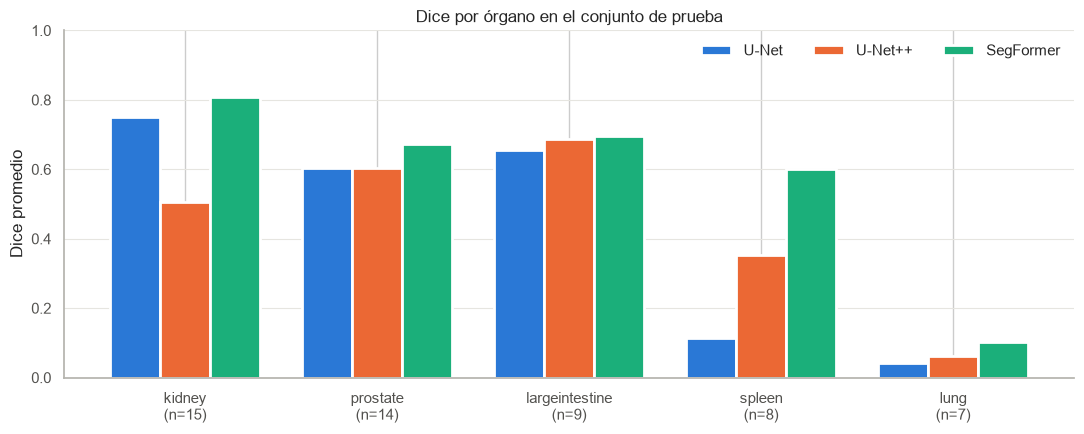

In [ ]:
fr.dice_por_organo(metricas)
plt.show()

SegFormer es el mejor en los cinco órganos. Las diferencias más grandes están en bazo, donde U-Net casi no detecta FTU (0.115 contra 0.602 de SegFormer), y en riñón, donde U-Net++ queda muy por debajo de los otros dos. El pulmón falla en los tres modelos (Dice ≤ 0.10).

### 4.3 Visualizaciones

Las figuras se guardan en `informe/figuras/` con el prefijo `resultados_`. También se pueden regenerar fuera del notebook con `uv run python -m informe.figuras_resultados`. La de Dice por órgano está en 4.2.

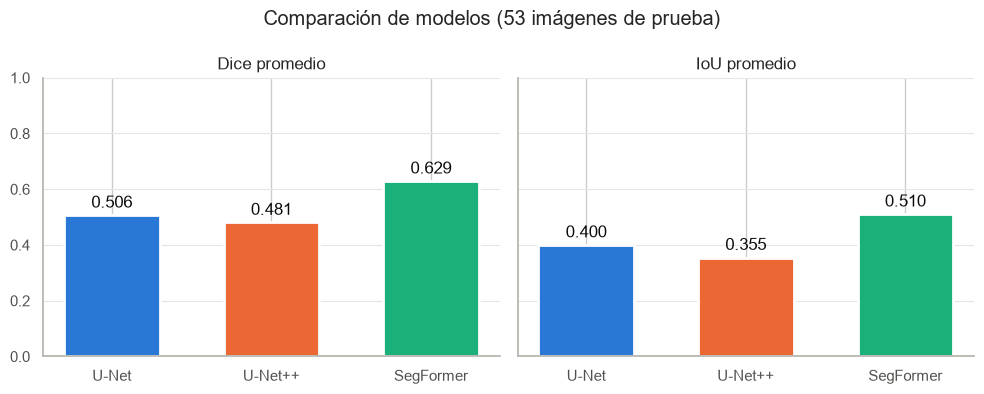

In [ ]:
fr.comparacion_modelos(metricas)
plt.show()

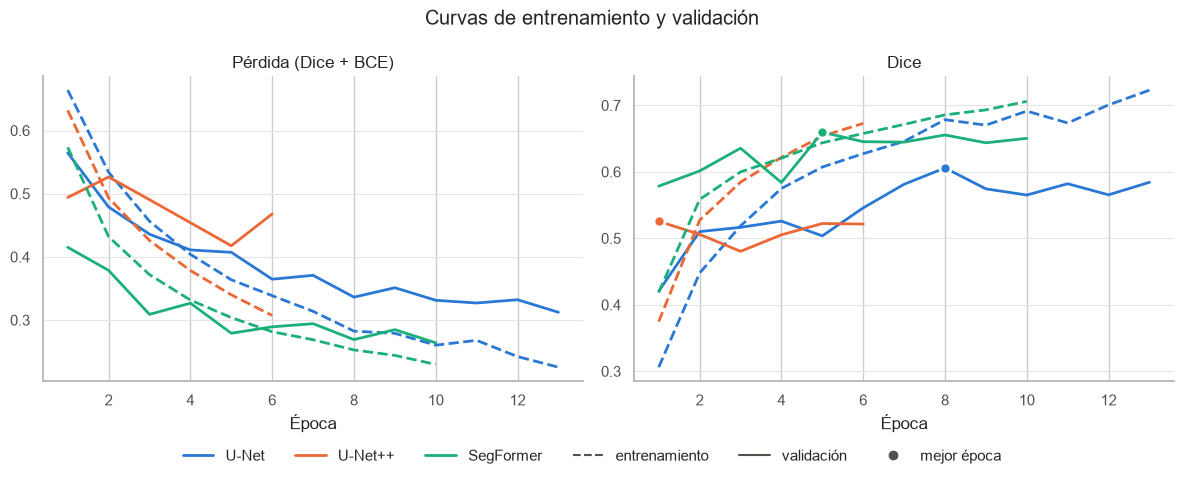

In [ ]:
historial = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "historial_modelos.csv"))
fr.curvas_entrenamiento(historial)
plt.show()

Para cada órgano se muestra la imagen de prueba cuyo Dice de SegFormer está más cerca de la mediana de ese órgano: un caso típico, no el mejor.

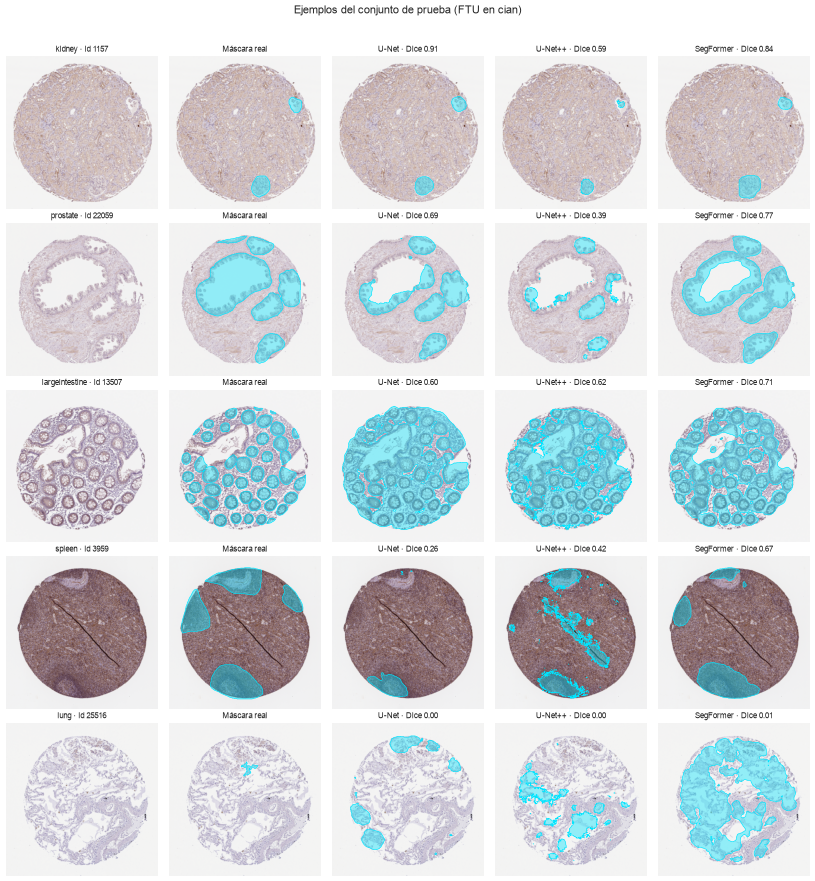

In [ ]:
if HAY_CACHE and HAY_CHECKPOINTS:
    fig = fr.ejemplos_prediccion(metricas, cache_dir=CACHE_DIR, checkpoints=RUTA_CHECKPOINTS)
    fig.set_dpi(55)  # solo en el notebook, para que no pese tanto
    plt.show()
else:
    print("Faltan la caché o los checkpoints. La figura guardada está en informe/figuras/resultados_ejemplos.png")

### 4.4 Discusión y selección del modelo

**Modelo seleccionado: SegFormer / MIT-B0.**

- Tiene el mayor Dice (0.629) y el mayor IoU (0.510) en prueba, y es el mejor en los cinco órganos. La mediana por imagen es 0.73.
- Es el que menos cae entre validación y prueba (0.660 → 0.629). U-Net cae 0.10, lo que indica que elegir la mejor época con solo 53 imágenes de validación le dio un número optimista.
- Tarda lo mismo que U-Net (~12 ms por imagen) y un tercio de lo que tarda U-Net++.
- Es el más ligero: 3.7 M de parámetros y un checkpoint de 15 MB, contra 24.4 M y 98 MB de U-Net y 26.1 M y 105 MB de U-Net++. Para la aplicación significa cargar rápido y poder correr en CPU.
- Coincide con lo que reporta el artículo del reto: SegFormer fue el mejor modelo individual (Jain et al., 2023a).

**Resultados por órgano y relación con el análisis exploratorio**

- **Riñón (0.81) e intestino grueso (0.70)** son los mejores, igual que en el reto. En intestino las FTU (criptas) ocupan cerca del 19 % de la imagen, la mayor proporción de los cinco órganos, y tienen forma regular. En riñón los glomérulos ocupan solo el 2.8 %, pero son compactos y redondos, y es el órgano con más imágenes (99 en total, 69 de entrenamiento).
- **Pulmón** es el peor en los tres modelos (Dice ≤ 0.10); con SegFormer, 4 de sus 7 imágenes de prueba quedan por debajo de 0.1. En el reto también fue el órgano más difícil, aunque los ganadores llegaron a 0.72–0.74. El análisis exploratorio ya lo anticipaba: es el órgano con la menor proporción de FTU (mediana de 1.3 %) y con pocas imágenes (48 en total, 34 de entrenamiento). En el ejemplo de 4.3 la máscara real es una región diminuta y los tres modelos marcan zonas grandes de tejido: confunden la estructura del pulmón con FTU. Al reducir las imágenes a 384 px, estructuras tan pequeñas quedan en muy pocos píxeles.
- **Bazo** separa a los modelos: SegFormer llega a 0.60, U-Net++ a 0.35 y U-Net a 0.12. Es de los órganos con menos imágenes (53) y su tinción es muy oscura. En el ejemplo, U-Net solo detecta una de las regiones y U-Net++ confunde una grieta del tejido con FTU.
- **U-Net++ en riñón (0.50)** queda muy por debajo de U-Net (0.75), a pesar de tener la misma arquitectura base. Es consistente con que se quedó con el checkpoint de la época 1.

**Limitaciones**

- **U-Net++ está subestimado.** Como se explicó en 3.5, el early stopping lo cortó en la época 1 mientras su Dice de entrenamiento seguía subiendo. Su último lugar refleja el protocolo de entrenamiento más que la arquitectura.
- **El conjunto de prueba es pequeño**: 53 imágenes en total y entre 7 y 15 por órgano. Una imagen mueve el promedio general casi 2 % y el de pulmón 14 %. La diferencia entre U-Net y U-Net++ (0.506 contra 0.481) no es concluyente; la ventaja de SegFormer (+0.12 sobre U-Net) sí, porque es grande y se repite en todos los órganos.
- **La brecha con los ganadores** (Dice ≈ 0.835) se explica por el perfil de entrenamiento: 384 px en lugar de resoluciones mayores, batch efectivo de 2, un solo modelo por arquitectura, la variante más pequeña de SegFormer (MIT-B0 contra MIT-B4) y sin datos externos, ensambles ni pseudo-etiquetado.

**Qué se podría mejorar:** entrenar U-Net++ con más paciencia o un batch efectivo mayor, usar parches a mayor resolución para el pulmón y probar una variante más grande de SegFormer.